# Updated Politeness package 2025

In this notebook, we demo how to extract meta data and summarised feature counts of politeness strategies using ConvoKit's `PolitenessStrategies` module for the latest updated version.

The updated version outputs two objects:
1. A pandas Series of feature prevalence for all politeness features
2. A dictionary of all politeness feature found in text where if found, list token, head, sentence number and word number within the sentence in the text

In [1]:
import sys
# sys.path.append('/Users/bb320/Library/CloudStorage/GoogleDrive-burint@bnmanalytics.com/My Drive/Imperial/01_Projects/convoKit_update/ConvoKit')
sys.path.append('/Users/bb320/Dev/ConvoKit')

import os
print(os.getcwd())

/Users/bb320/Dev/ConvoKit/examples/politeness-strategies


### Politeness Features and Markers

Here we add the politeness strategy information. By default, we obtain features considered in Stanford Politeness API. This choice can be changed by explicitly specifying the strategy collection of choice, e.g., `ps = PolitenessStrategies(strategy_collection="politeness_2025"`) will extract only local politeness strategies.

In [2]:
Text = """
From a Mexican perspective, the U.S. decision to raise tariffs is both bewildering and infuriating.
While some may argue that this policy reflects legitimate concerns about protecting American industries,
it also feels like an unnecessary and arrogant disruption to a deeply interdependent economic relationship.
Admittedly, every nation has a right to defend its interests, but this approach seems shortsighted, especially given the promises of cooperation under the USMCA.
Frankly, it’s hard not to view this as a betrayal—a decision that disregards years of trust and mutual benefit for the sake of political posturing.
It may be justified in theory, but in practice, it risks damaging countless livelihoods and creating unnecessary animosity between neighbors.
"""

Text_list = ["Hello, how are you?", "I'm great thanks! How about you?", "I'm doing well, thanks for asking!"]

#### Computing politeness feature prevalance and extract meta data

As a summary of politeness features used in a single document, use `feature_counts()`.
To view more detailed information on each politeness feature, use `meta_strategies()` to 
    a) view which tokens, head, sentence number and word number in the sentence, and
    b) view the feature counts in a dictionary format.

In [25]:
from convokit import PolitenessStrategies
ps = PolitenessStrategies(strategy_collection="politeness_2025") # Instantiate PolitenessStrategies

features = ps.feature_counts(Text)
meta = ps.meta_strategies(Text)


Processing text for politeness strategies...
Processing text for politeness strategies...


In [11]:
print(features)
print(meta['politeness_markers'])
print(meta['politeness_strategies'])

Agreement                0
Apology                  0
Third_Person             0
Contrast_Conjunction     4
Ask_Agency               0
By_The_Way               0
Can_You                  0
Could_You                0
Disagreement             0
Filler_Pause             0
First_Person_Plural      0
First_Person_Single      0
For_Me                   0
For_You                  0
Formal_Title             0
Give_Agency              0
Goodbye                  0
Gratitude                0
Hedges                   6
Hello                    0
Impersonal_Pronoun      30
Informal_Title           0
Let_Me_Know              0
Negation                 1
Negative_Emotion        16
Please                   0
Positive_Emotion         6
Reasoning                0
Reassurance              0
Second_Person            0
Swearing                 0
Truth_Intensifier        0
Acknowledgement          0
Subjectivity             0
Affirmation              0
Conjunction_Start        0
Bare_Command             0
W

Testing on different question types

In [14]:
from convokit import PolitenessStrategies
ps = PolitenessStrategies(strategy_collection="politeness_2025") # Instantiate PolitenessStrategies

Text = "Ok so which part should we do first? the first or second?"
# Text = "I understand, can you help me with this task?"

features = ps.feature_counts(Text)
meta = ps.meta_strategies(Text)
print(meta['politeness_markers'])

print("WH Questions:")
print(meta['politeness_markers']['WH_Questions'])
print("Yes/No Questions:")
print(meta['politeness_markers']['YesNo_Questions'])
print("can you:")
print(meta['politeness_markers']['Can_You'])


Processing text for politeness strategies...
Processing text for politeness strategies...
{'Agreement': [], 'Apology': [], 'Third_Person': [], 'Contrast_Conjunction': [], 'Ask_Agency': [], 'By_The_Way': [], 'Can_You': [], 'Could_You': [], 'Disagreement': [], 'Filler_Pause': [], 'First_Person_Plural': [['we', 'do', 1, 6]], 'First_Person_Single': [], 'For_Me': [], 'For_You': [], 'Formal_Title': [], 'Give_Agency': [], 'Goodbye': [], 'Gratitude': [], 'Hedges': [['should', 'do', 1, 5]], 'Hello': [], 'Impersonal_Pronoun': [['which', 'part', 1, 3]], 'Informal_Title': [], 'Let_Me_Know': [], 'Negation': [], 'Negative_Emotion': [], 'Please': [], 'Positive_Emotion': [], 'Reasoning': [], 'Reassurance': [], 'Second_Person': [], 'Swearing': [], 'Truth_Intensifier': [], 'Acknowledgement': [], 'Subjectivity': [], 'Affirmation': [['ok', 'do', 1, 1]], 'Conjunction_Start': [], 'Bare_Command': [], 'WH_Questions': [['which', 'part', 1, 3]], 'YesNo_Questions': [['the', 'first', 2, 1]], 'Adverb_Limiters': []

We can also apply this function to lists or a column of texts. However, calling feature_conts() would now return a dataframe of feature counts rather than a Pandas Series.

In [5]:
from convokit import PolitenessStrategies
ps = PolitenessStrategies(strategy_collection="politeness_2025") # Instantiate PolitenessStrategies

features = ps.feature_counts(Text_list)
meta = ps.meta_strategies(Text_list)

Processing text for politeness strategies...
Processing text for politeness strategies...


In [6]:
features

,Agreement,Apology,Third_Person,Contrast_Conjunction,Ask_Agency,By_The_Way,Can_You,Could_You,Disagreement,Filler_Pause,...,Swearing,Truth_Intensifier,Acknowledgement,Subjectivity,Affirmation,Conjunction_Start,Bare_Command,WH_Questions,YesNo_Questions,Adverb_Limiters
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We can also quickly visualize feature occurence per text, distribution of those features (box plot), and feature occurence per text per 100 words.

Processing text for politeness strategies...
Processing text for politeness strategies...


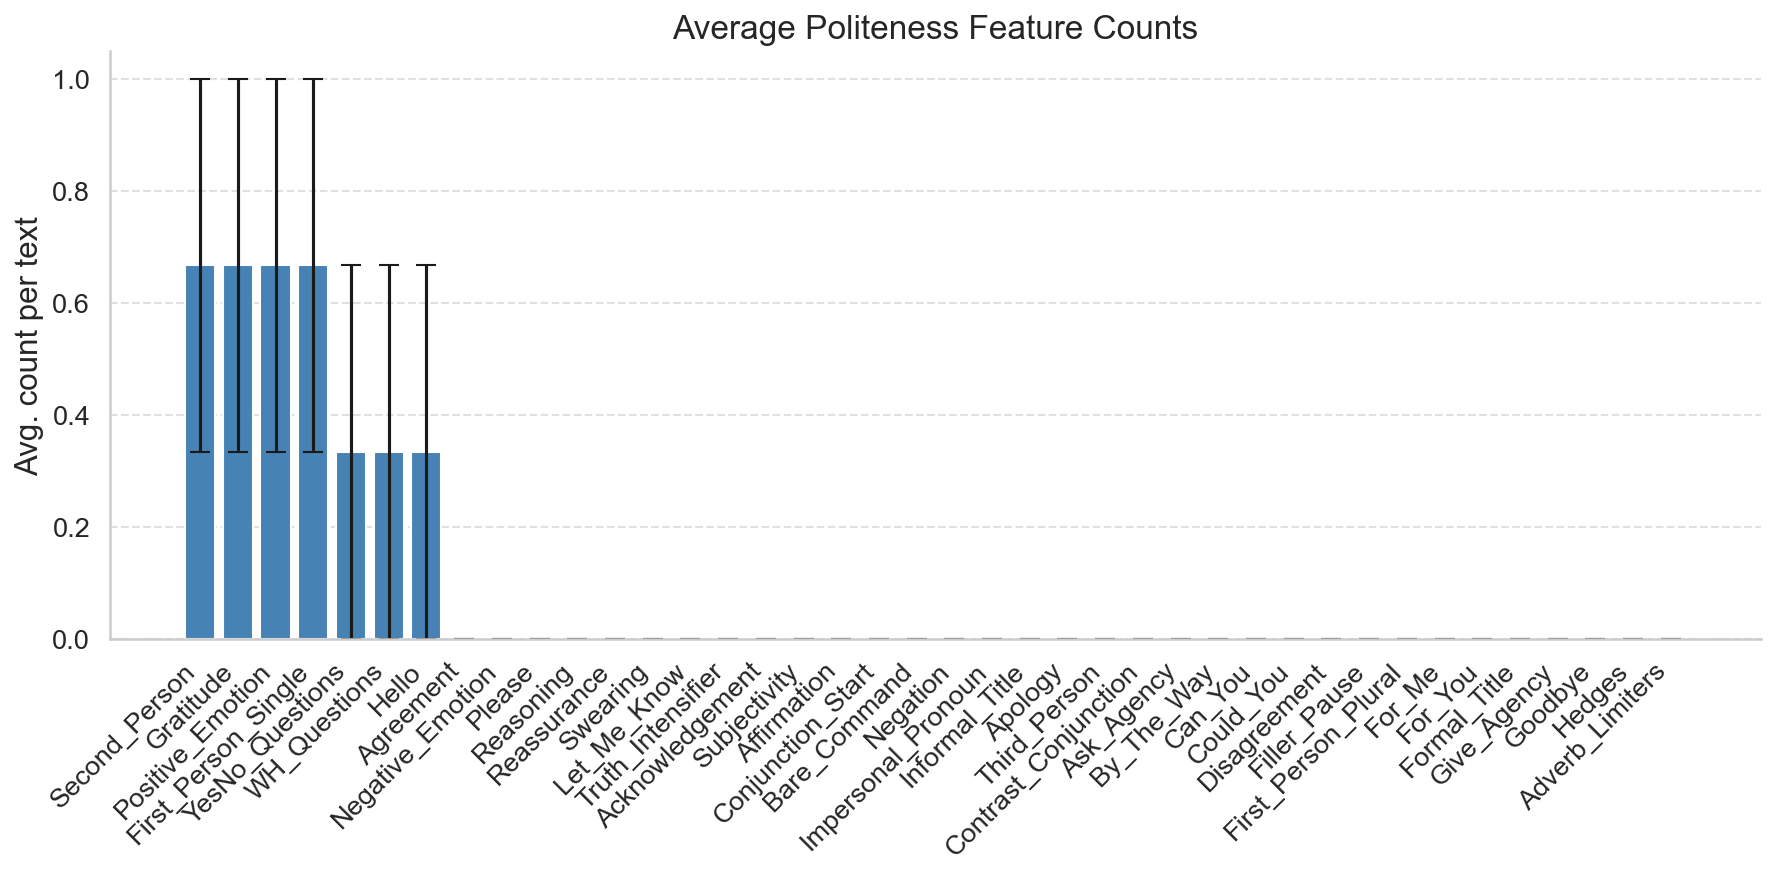

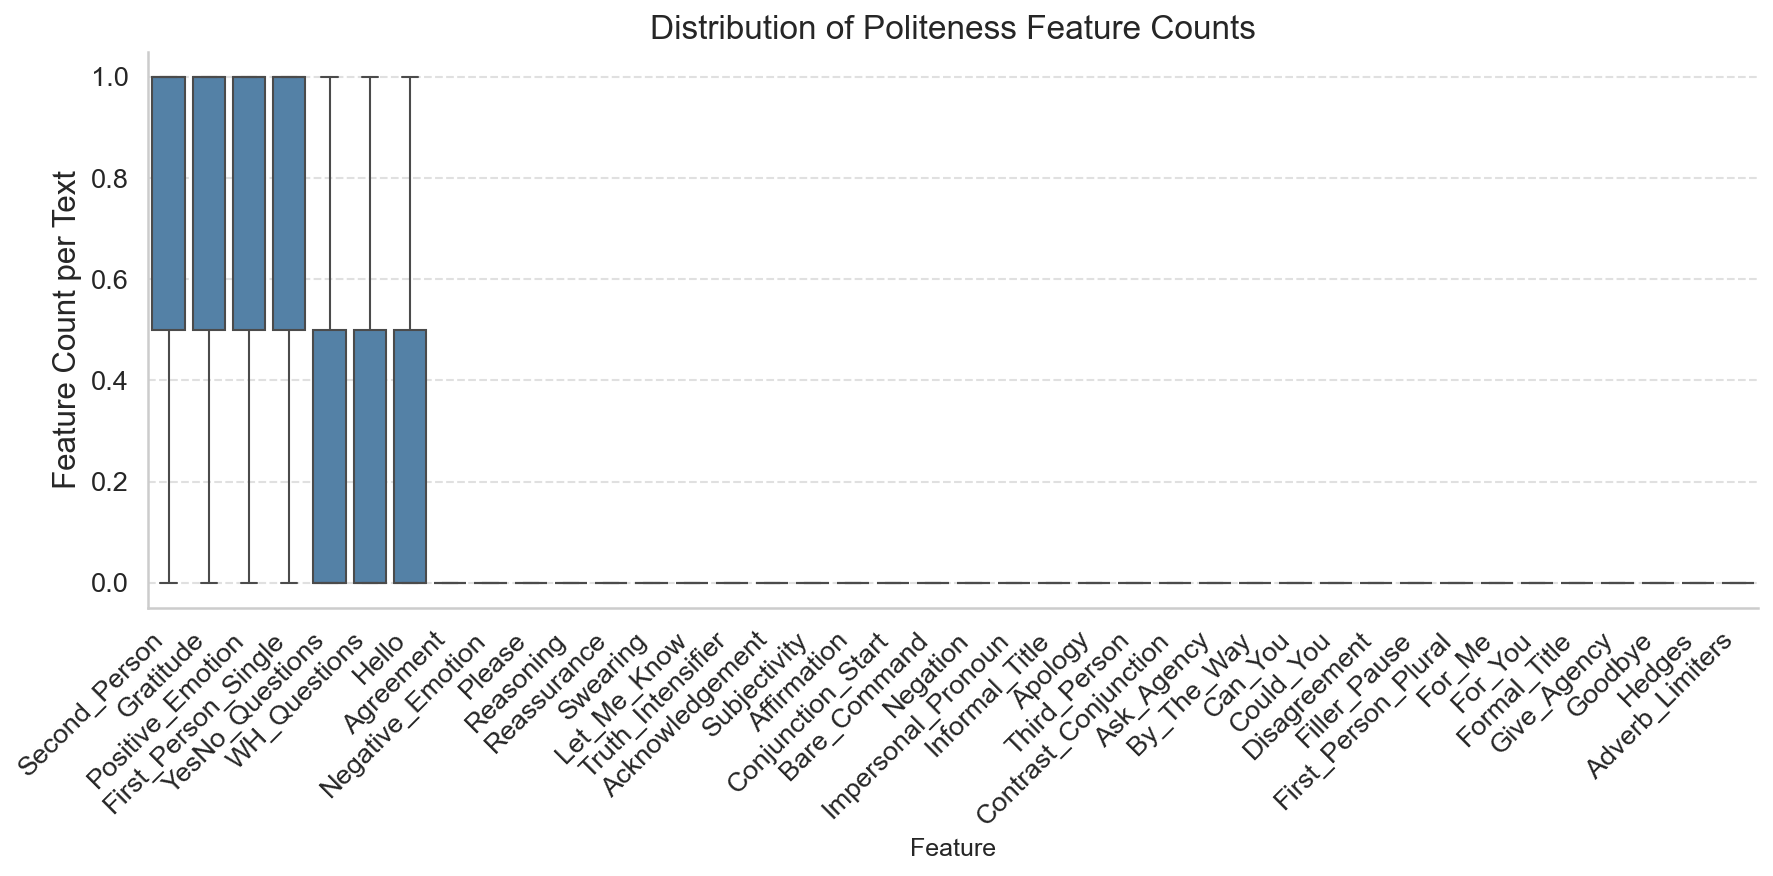

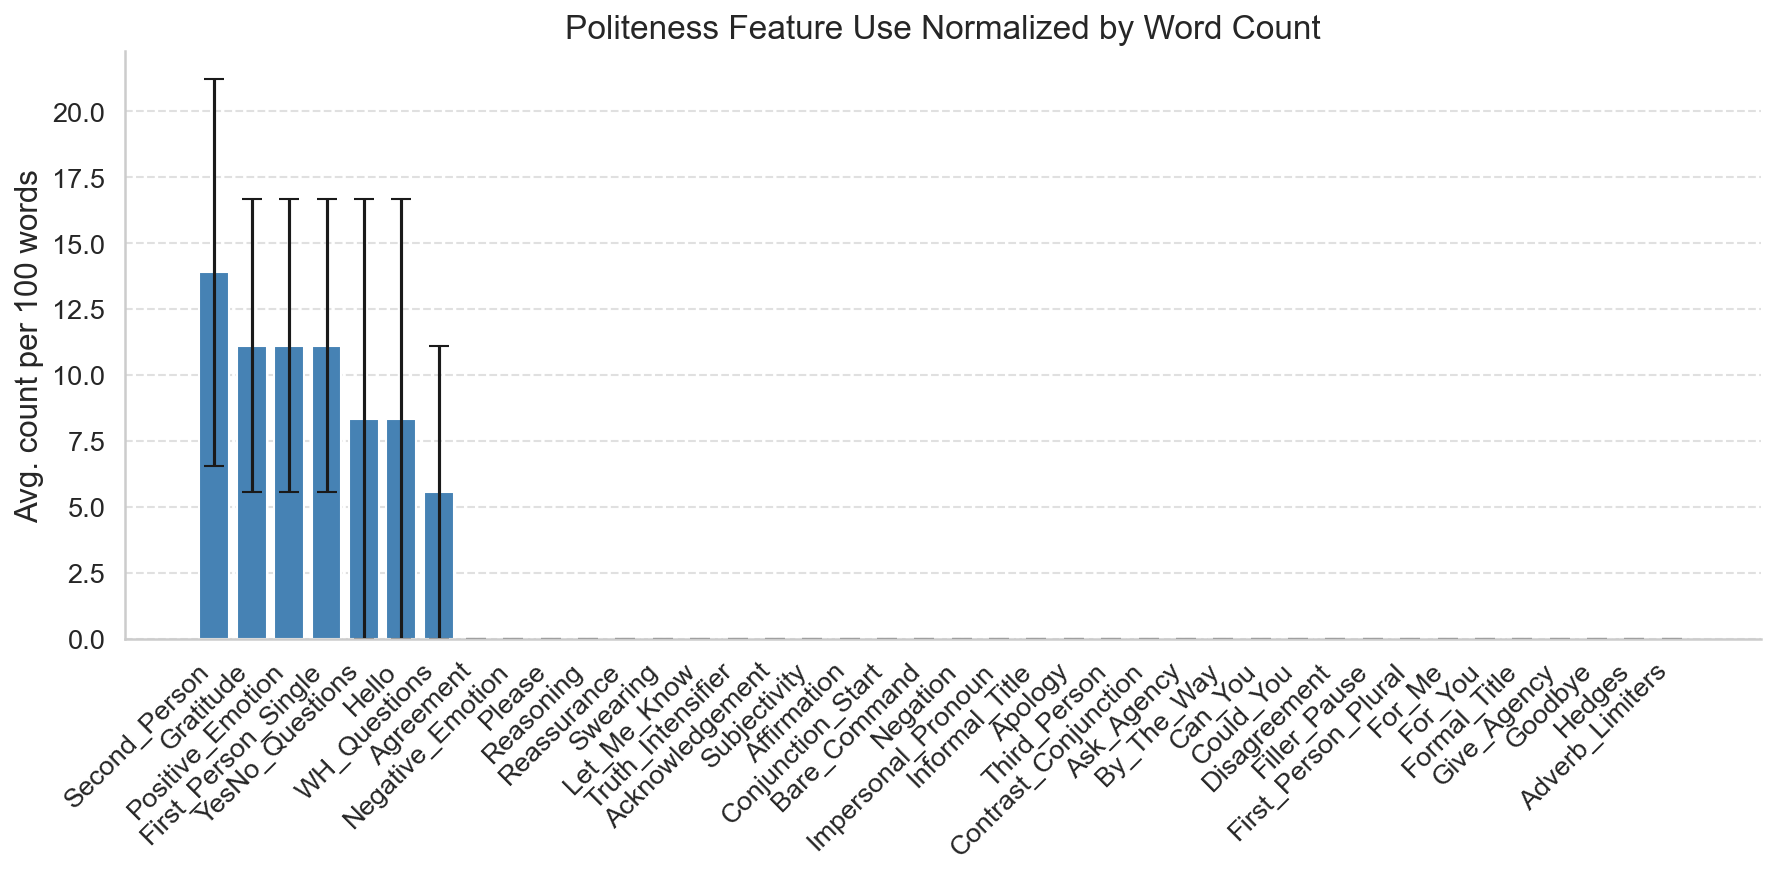

In [7]:
from convokit.politeness_collections.politeness_2025.plot_politeness_features import plot_politeness_features

features, meta = ps.feature_counts(Text_list), ps.meta_strategies(Text_list)
word_counts = [len(t.split()) for t in Text_list]  # crude word count per text
plot_politeness_features(features, word_counts)


Below is an example of politeness strategy data for a single documtent

In [8]:
meta[0]['politeness_strategies']

{'feature_politeness_==Agreement==': 0,
 'feature_politeness_==Apology==': 0,
 'feature_politeness_==Third_Person==': 0,
 'feature_politeness_==Contrast_Conjunction==': 0,
 'feature_politeness_==Ask_Agency==': 0,
 'feature_politeness_==By_The_Way==': 0,
 'feature_politeness_==Can_You==': 0,
 'feature_politeness_==Could_You==': 0,
 'feature_politeness_==Disagreement==': 0,
 'feature_politeness_==Filler_Pause==': 0,
 'feature_politeness_==First_Person_Plural==': 0,
 'feature_politeness_==First_Person_Single==': 0,
 'feature_politeness_==For_Me==': 0,
 'feature_politeness_==For_You==': 0,
 'feature_politeness_==Formal_Title==': 0,
 'feature_politeness_==Give_Agency==': 0,
 'feature_politeness_==Goodbye==': 0,
 'feature_politeness_==Gratitude==': 0,
 'feature_politeness_==Hedges==': 0,
 'feature_politeness_==Hello==': 1,
 'feature_politeness_==Impersonal_Pronoun==': 0,
 'feature_politeness_==Informal_Title==': 0,
 'feature_politeness_==Let_Me_Know==': 0,
 'feature_politeness_==Negation==':

In [9]:
meta[0]['politeness_markers']

{'Agreement': [],
 'Apology': [],
 'Third_Person': [],
 'Contrast_Conjunction': [],
 'Ask_Agency': [],
 'By_The_Way': [],
 'Can_You': [],
 'Could_You': [],
 'Disagreement': [],
 'Filler_Pause': [],
 'First_Person_Plural': [],
 'First_Person_Single': [],
 'For_Me': [],
 'For_You': [],
 'Formal_Title': [],
 'Give_Agency': [],
 'Goodbye': [],
 'Gratitude': [],
 'Hedges': [],
 'Hello': [['hello', 'are', 1, 1]],
 'Impersonal_Pronoun': [],
 'Informal_Title': [],
 'Let_Me_Know': [],
 'Negation': [],
 'Negative_Emotion': [],
 'Please': [],
 'Positive_Emotion': [],
 'Reasoning': [],
 'Reassurance': [],
 'Second_Person': [['you', 'are', 1, 5]],
 'Swearing': [],
 'Truth_Intensifier': [],
 'Acknowledgement': [],
 'Subjectivity': [],
 'Affirmation': [],
 'Conjunction_Start': [],
 'Bare_Command': [],
 'WH_Questions': [],
 'YesNo_Questions': [['hello', 'are', 1, 1]],
 'Adverb_Limiters': []}